<a href="https://colab.research.google.com/github/NBK-code/Demonstrations/blob/main/Multi_Armed_Bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Bandit Class

Create Bandit class. Each arm gives a reward of +1 when pulled, otherwise 0.

In [12]:
class BanditEnv:
  def __init__(self, probs):
    self.probs = probs
    self.n_arms = len(probs)
    self.best_arm = np.argmax(probs)

  def pull(self, arm):
    return 1 if np.random.rand() < self.probs[arm] else 0

#Epsilon Greedy

Explore N arms with probablity ϵ, and exploit the best arm so far, with probability 1 - ϵ.

In [13]:
def epsilon_greedy(env, steps = 2000, epsilon = 0.1):

  n_arms = env.n_arms
  counts = np.zeros(n_arms)
  values = np.zeros(n_arms)

  optim = []

  for t in range(steps):

    if np.random.rand() < epsilon: #Explore
      arm = np.random.randint(n_arms)
    else:
      arm = np.argmax(values)

    reward = env.pull(arm)

    counts[arm] += 1
    values[arm] += (1/counts[arm])*(reward - values[arm])

    optim.append(arm == env.best_arm)

  return np.cumsum(optim)/ np.arange(1, steps + 1)

#Upper Confidence Bound

Choose arm optimistically.

$a = arg max_a (Q_t(a) + c \sqrt(\ln(t)/n_a) )$

In [14]:
def ucb(env, steps = 2000, c = 2.0):

  n_arms = env.n_arms
  counts = np.zeros(n_arms)
  values = np.zeros(n_arms)

  optim = []

  for t in range(steps):
    # Explore all arms at least once
    if t < n_arms:
      arm = t
    else:
      ucb_values = values + c * np.sqrt(np.log(t) / counts)
      arm = np.argmax(ucb_values)

    reward = env.pull(arm)

    counts[arm] += 1
    values[arm] += (1/counts[arm]) * (reward - values[arm])

    optim.append(arm == env.best_arm)

  return np.cumsum(optim) / np.arange(1, steps + 1)

#Thompson Sampling

We start from a prior distribution

$P(\theta) = Beta(\alpha, \beta) = \theta^{\alpha - 1}(1-\theta)^{\beta - 1}$

and update according to the rule:

$\alpha = \alpha + successes$

in case of success and

$\beta = \beta + failures$

in case of failure to get a reward of 1.


In [27]:
def thompson(env, steps = 2000):

  n_arms = env.n_arms
  alpha = np.ones(n_arms)
  beta = np.ones(n_arms)

  optim = []

  for t in range(steps):

    #Draw from prior distribution
    samples = np.random.beta(alpha, beta)
    arm = np.argmax(samples)

    reward = env.pull(arm)

    #Update to get posterior
    if reward == 1:
      alpha[arm] += 1
    else:
      beta[arm] += 1

    optim.append(arm == env.best_arm)

  return np.cumsum(optim) / np.arange(1, steps + 1)

In [37]:
probs = [0.6, 0.8, 0.4]
env = BanditEnv(probs)

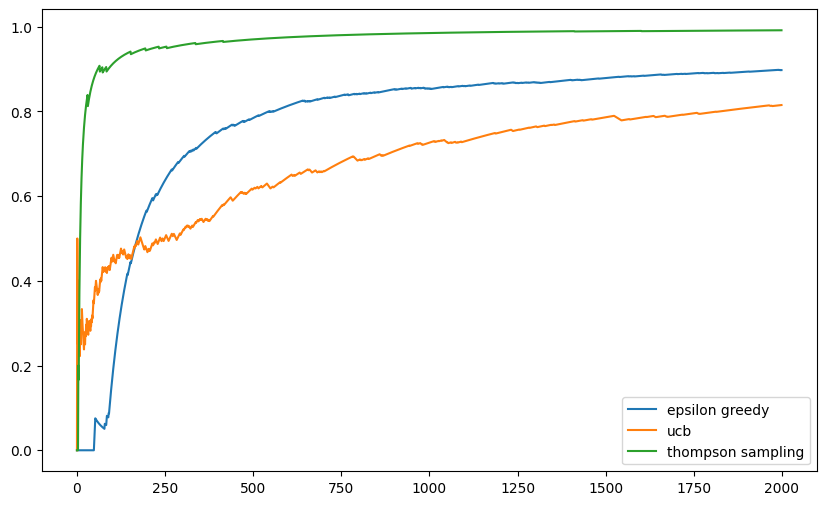

In [38]:
epsilon_greedy_optim = epsilon_greedy(env)
ucb_optim = ucb(env)
thompson_optim = thompson(env)

plt.figure(figsize = (10,6))
plt.plot(epsilon_greedy_optim, label = "epsilon greedy")
plt.plot(ucb_optim, label = "ucb")
plt.plot(thompson_optim, label = "thompson sampling")
plt.legend()
plt.show()

In [33]:
steps = 5000
trials = 200

eps_runs = np.zeros((trials, steps))
ucb_runs = np.zeros((trials, steps))
ts_runs = np.zeros((trials, steps))

for i in range(trials):

    env = BanditEnv([0.3, 0.5, 0.7])

    eps_runs[i] = epsilon_greedy(env, steps)
    ucb_runs[i] = ucb(env, steps)
    ts_runs[i] = thompson(env, steps)

In [34]:
eps_mean = eps_runs.mean(axis=0)
eps_std = eps_runs.std(axis=0)

ucb_mean = ucb_runs.mean(axis=0)
ucb_std = ucb_runs.std(axis=0)

ts_mean = ts_runs.mean(axis=0)
ts_std = ts_runs.std(axis=0)

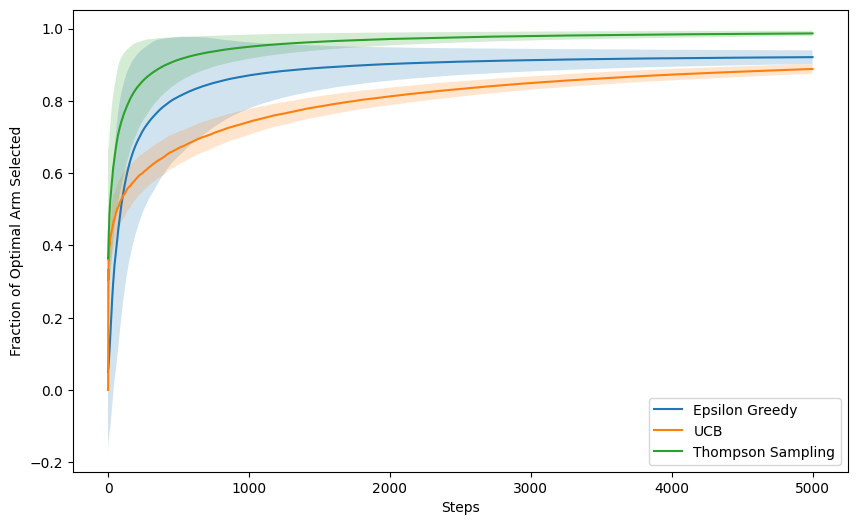

In [35]:
x = np.arange(steps)

plt.figure(figsize=(10,6))

# epsilon greedy
plt.plot(x, eps_mean, label="Epsilon Greedy")
plt.fill_between(
    x,
    eps_mean - eps_std,
    eps_mean + eps_std,
    alpha=0.2
)

# UCB
plt.plot(x, ucb_mean, label="UCB")
plt.fill_between(
    x,
    ucb_mean - ucb_std,
    ucb_mean + ucb_std,
    alpha=0.2
)

# Thompson sampling
plt.plot(x, ts_mean, label="Thompson Sampling")
plt.fill_between(
    x,
    ts_mean - ts_std,
    ts_mean + ts_std,
    alpha=0.2
)

plt.xlabel("Steps")
plt.ylabel("Fraction of Optimal Arm Selected")
plt.legend()
plt.show()

In production systems, epsilson greedy is used for simple systems and to get baselines while Thompson sampling is used in most practical large scale systems.